# **Project Name**    -
HOUSE PRICE PREDICTION


##### **Contribution**    - Individual
#####  Member Name  - DEVADHARSHINI M


# GitHub Link - Models saved
https://github.com/devadharshinimurugan06-commits/Syntecxhub_project_House_Price_Prediction.git

# **Streamlit App Link for House Price Prediction -**
https://devadharshinisyntecxhousepriceprediction-cugpatz9iswrxnne5bovcq.streamlit.app/

Provide your GitHub Link here.

In [44]:
# IMPORT REQUIRED LIBRARIES


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Machine Learning model
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

print("All required libraries imported successfully!")

All required libraries imported successfully!


In [45]:

# LOAD DATASET FROM GITHUB


github_raw_url = "https://raw.githubusercontent.com/devadharshinimurugan06-commits/Syntecxhub_project_House_Price_Prediction/main/house_price_prediction.csv"

df = pd.read_csv(github_raw_url)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (7045, 13)


,House_ID,Property_Code,Area_Sqft,Bedrooms,Bathrooms,Age_Years,Location,Furnishing_Status,Property_Type,Parking_Spaces,Garden_Available,Distance_To_City_Center_Km,Price
0,1,HP-2018-10000,2548.0,1,1,5.0,Urban,Semi-Furnished,Studio,3,0,3.6,428225.0
1,2,HP-2019-10001,2103.0,2,1,2.0,Suburban,Semi-Furnished,Apartment,1,0,1.3,414559.0
2,3,HP-2020-10002,2653.0,3,2,3.0,Urban,Semi-Furnished,Apartment,2,0,3.0,560716.0
3,4,HP-2021-10003,3266.0,4,3,3.0,Suburban,Semi-Furnished,Villa,1,1,3.2,775550.0
4,5,HP-2022-10004,2036.0,2,1,16.0,Urban,Semi-Furnished,Independent House,1,0,8.3,429372.0


In [46]:

#  BASIC DATASET INFORMATION

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Number of Rows: 7045
Number of Columns: 13

Column Names:
['House_ID', 'Property_Code', 'Area_Sqft', 'Bedrooms', 'Bathrooms', 'Age_Years', 'Location', 'Furnishing_Status', 'Property_Type', 'Parking_Spaces', 'Garden_Available', 'Distance_To_City_Center_Km', 'Price']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7045 entries, 0 to 7044
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   House_ID                    7045 non-null   int64  
 1   Property_Code               7045 non-null   object 
 2   Area_Sqft                   6835 non-null   float64
 3   Bedrooms                    7045 non-null   int64  
 4   Bathrooms                   7045 non-null   int64  
 5   Age_Years                   6835 non-null   float64
 6   Location                    7045 non-null   object 
 7   Furnishing_Status           6835 non-null   object 
 8   Property_Type               70

In [47]:
# STATISTICAL SUMMARY

print("Statistical Summary:")
display(df.describe(include="all").T)

Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
House_ID,7045.0,NaN,NaN,NaN,3499.533712,2021.173256,1.0,1751.0,3497.0,5252.0,7000.0
Property_Code,7045,7000,HP-2024-16362,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area_Sqft,6835.0,NaN,NaN,NaN,2227.162717,798.377378,500.0,1732.0,2201.0,2677.0,10901.358123
Bedrooms,7045.0,NaN,NaN,NaN,3.353584,1.222321,1.0,2.0,3.0,4.0,6.0
Bathrooms,7045.0,NaN,NaN,NaN,2.074379,0.905926,1.0,1.0,2.0,3.0,5.0
Age_Years,6835.0,NaN,NaN,NaN,12.033245,12.217392,0.0,3.0,8.0,16.0,108.084513
Location,7045,4,Urban,2436,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Furnishing_Status,6835,18,Semi-Furnished,2338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Property_Type,7045,4,Apartment,3182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Parking_Spaces,7045.0,NaN,NaN,NaN,1.3445,0.851469,0.0,1.0,1.0,2.0,3.0


In [48]:

#  CHECK MISSING VALUES

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Column": df.columns,
    "Missing_Values": missing_values.values,
    "Missing_Percentage": (missing_values.values / len(df)) * 100
})

display(missing_table)

,Column,Missing_Values,Missing_Percentage
0,House_ID,0,0.000000
1,Property_Code,0,0.000000
2,Area_Sqft,210,2.980837
3,Bedrooms,0,0.000000
4,Bathrooms,0,0.000000
5,Age_Years,210,2.980837
6,Location,0,0.000000
7,Furnishing_Status,210,2.980837
8,Property_Type,0,0.000000
9,Parking_Spaces,0,0.000000


In [49]:

# CHECK DUPLICATE ROWS


duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 44


In [50]:

# REMOVE DUPLICATE ROWS


df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (7001, 13)


In [51]:

# INSPECT CATEGORICAL COLUMNS


categorical_columns = [
    "Location",
    "Furnishing_Status",
    "Property_Type"
]

for column in categorical_columns:
    print("\n" + "=" * 60)
    print("COLUMN:", column)
    print("=" * 60)
    print(df[column].value_counts(dropna=False))


COLUMN: Location
Location
Urban       2416
Suburban    2124
Downtown    1415
Rural       1046
Name: count, dtype: int64

COLUMN: Furnishing_Status
Furnishing_Status
Semi-Furnished     2336
Unfurnished        1778
Furnished          1644
NaN                 210
SEMI-FURNISHED       94
semi-furnished       92
Semi_Furnished       89
furnished            85
#Semi-Furnished      82
Furnished            71
Semi Furnished       71
 Unfurnished         64
 Furnished           64
unfurnished          59
FURNISHED            58
UNFURNISHED          56
#Furnished           52
Un-furnished         48
#Unfurnished         48
Name: count, dtype: int64

COLUMN: Property_Type
Property_Type
Apartment            3162
Independent House    1719
Villa                1097
Studio               1023
Name: count, dtype: int64


In [52]:

#  STANDARDIZE CATEGORICAL VALUES


# Standardize Location
df["Location"] = (
    df["Location"]
    .astype("string")
    .str.strip()
    .str.replace("_", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.title()
)

# Standardize Furnishing_Status
df["Furnishing_Status"] = (
    df["Furnishing_Status"]
    .astype("string")
    .str.strip()
    .str.replace("#", "", regex=False)
    .str.replace("_", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.title()
)

# Standardize Property_Type
df["Property_Type"] = (
    df["Property_Type"]
    .astype("string")
    .str.strip()
    .str.replace("_", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.title()
)

print("Categorical values standardized successfully!")

Categorical values standardized successfully!


In [53]:
for column in categorical_columns:
    print("\n", column)
    print(df[column].value_counts(dropna=False))


 Location
Location
Urban       2416
Suburban    2124
Downtown    1415
Rural       1046
Name: count, dtype: Int64

 Furnishing_Status
Furnishing_Status
Semi-Furnished    2604
Unfurnished       2005
Furnished         1974
<NA>               210
Semi Furnished     160
Un-Furnished        48
Name: count, dtype: Int64

 Property_Type
Property_Type
Apartment            3162
Independent House    1719
Villa                1097
Studio               1023
Name: count, dtype: Int64


In [54]:

# TARGET VARIABLE ANALYSIS


print("Target Variable: Price")

print("\nPrice Data Type:")
print(df["Price"].dtype)

print("\nPrice Summary:")
print(df["Price"].describe())

print("\nMissing Price Values:")
print(df["Price"].isnull().sum())

Target Variable: Price

Price Data Type:
float64

Price Summary:
count    7.001000e+03
mean     5.193394e+05
std      1.395512e+05
min      7.071700e+04
25%      4.282010e+05
50%      5.126030e+05
75%      6.004470e+05
max      1.768638e+06
Name: Price, dtype: float64

Missing Price Values:
0


In [55]:

#  FINAL CATEGORICAL CLEANING


# Standardize furnishing categories into exactly 3 groups
df["Furnishing_Status"] = df["Furnishing_Status"].replace({
    "Semi Furnished": "Semi-Furnished",
    "Semi-Furnished": "Semi-Furnished",
    "Un-Furnished": "Unfurnished",
    "Unfurnished": "Unfurnished",
    "Furnished": "Furnished"
})

print("Final Furnishing_Status categories:")
print(df["Furnishing_Status"].value_counts(dropna=False))

Final Furnishing_Status categories:
Furnishing_Status
Semi-Furnished    2764
Unfurnished       2053
Furnished         1974
<NA>               210
Name: count, dtype: Int64


In [56]:

# STEP 11: VERIFY CLEANED DATASET

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nFurnishing Categories:")
print(df["Furnishing_Status"].value_counts(dropna=False))

Dataset Shape: (7001, 13)

Missing Values:
House_ID                        0
Property_Code                   0
Area_Sqft                     210
Bedrooms                        0
Bathrooms                       0
Age_Years                     210
Location                        0
Furnishing_Status             210
Property_Type                   0
Parking_Spaces                  0
Garden_Available                0
Distance_To_City_Center_Km    210
Price                           0
dtype: int64

Duplicate Rows:
0

Furnishing Categories:
Furnishing_Status
Semi-Furnished    2764
Unfurnished       2053
Furnished         1974
<NA>               210
Name: count, dtype: Int64


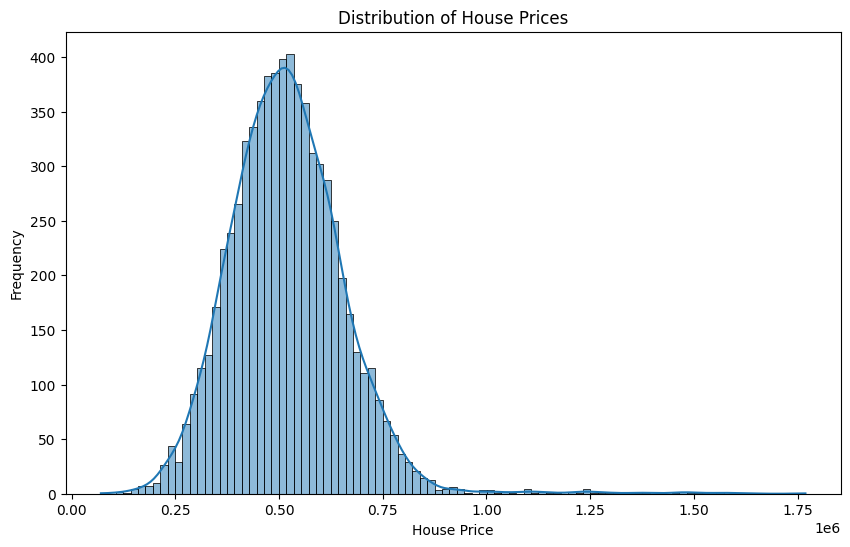

In [57]:

#  PRICE DISTRIBUTION


plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Price",
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.show()

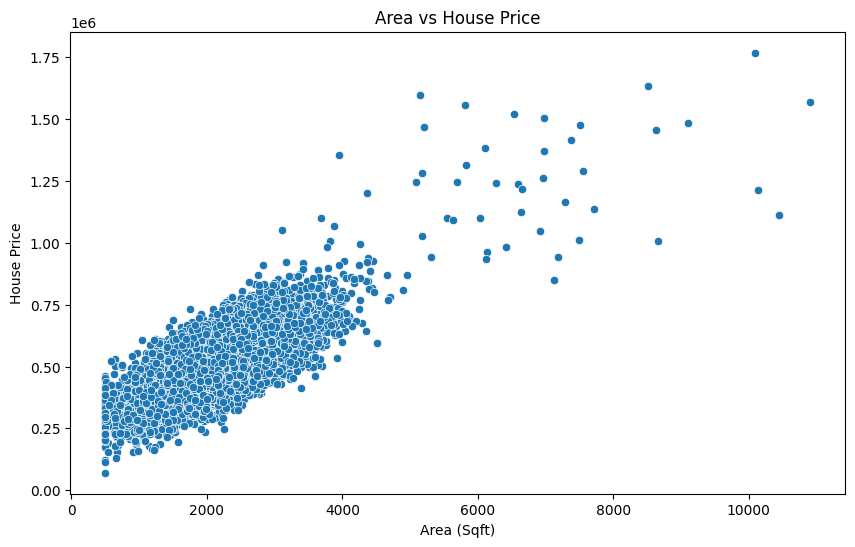

In [58]:

#  AREA VS HOUSE PRICE


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Area_Sqft",
    y="Price"
)

plt.title("Area vs House Price")
plt.xlabel("Area (Sqft)")
plt.ylabel("House Price")

plt.show()

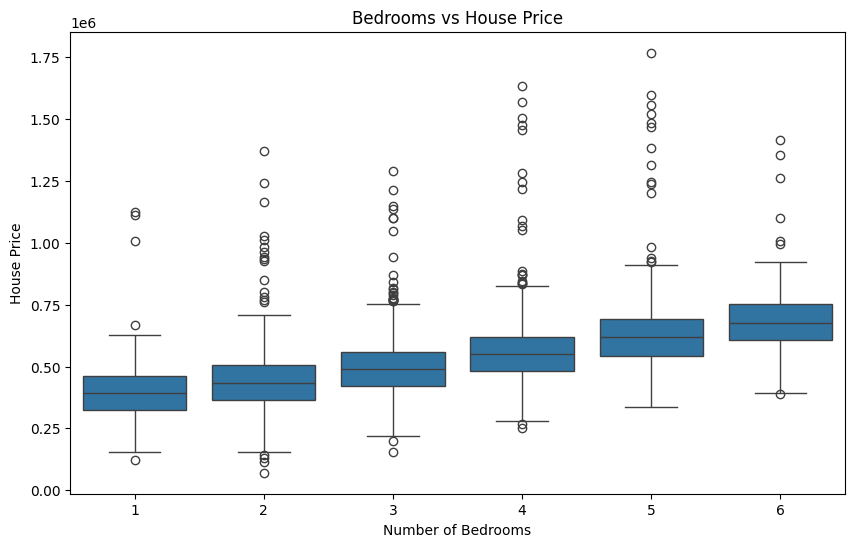

In [59]:

# BEDROOMS VS HOUSE PRICE


plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Bedrooms",
    y="Price"
)

plt.title("Bedrooms vs House Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("House Price")

plt.show()

In [60]:

#  FEATURE SELECTION


features = [
    "Area_Sqft",
    "Bedrooms",
    "Bathrooms",
    "Age_Years",
    "Location",
    "Furnishing_Status",
    "Property_Type",
    "Parking_Spaces",
    "Garden_Available",
    "Distance_To_City_Center_Km"
]

target = "Price"

X = df[features].copy()
y = df[target].copy()

print("Selected Features:")
for feature in features:
    print("-", feature)

print("\nTarget Variable:", target)

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)

Selected Features:
- Area_Sqft
- Bedrooms
- Bathrooms
- Age_Years
- Location
- Furnishing_Status
- Property_Type
- Parking_Spaces
- Garden_Available
- Distance_To_City_Center_Km

Target Variable: Price

X Shape: (7001, 10)
y Shape: (7001,)


In [61]:

# TRAIN / TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape :", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape :", y_test.shape)

Training data shape: (5600, 10)
Testing data shape : (1401, 10)

Training target shape: (5600,)
Testing target shape : (1401,)


In [62]:

# DEFINE FEATURE TYPES


numeric_features = [
    "Area_Sqft",
    "Bedrooms",
    "Bathrooms",
    "Age_Years",
    "Parking_Spaces",
    "Garden_Available",
    "Distance_To_City_Center_Km"
]

categorical_features = [
    "Location",
    "Furnishing_Status",
    "Property_Type"
]

print("Numerical Features:")
for feature in numeric_features:
    print("-", feature)

print("\nCategorical Features:")
for feature in categorical_features:
    print("-", feature)

Numerical Features:
- Area_Sqft
- Bedrooms
- Bathrooms
- Age_Years
- Parking_Spaces
- Garden_Available
- Distance_To_City_Center_Km

Categorical Features:
- Location
- Furnishing_Status
- Property_Type


In [63]:

# PREPROCESSING PIPELINE

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [64]:

# LINEAR REGRESSION MODEL


# Make copies so the original X_train/X_test are not modified
X_train_lr = X_train.copy()
X_test_lr = X_test.copy()

# Convert pandas nullable NA values to NumPy NaN
# This allows sklearn's SimpleImputer to handle missing values correctly
X_train_lr = X_train_lr.astype(object).where(
    pd.notna(X_train_lr),
    np.nan
)

X_test_lr = X_test_lr.astype(object).where(
    pd.notna(X_test_lr),
    np.nan
)

# ------------------------------------------------------------
# Numerical preprocessing
# ------------------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# ------------------------------------------------------------
# Categorical preprocessing
# ------------------------------------------------------------

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
                sparse_output=False
            )
        )
    ]
)

# ------------------------------------------------------------
# Combined preprocessing
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# ------------------------------------------------------------
# Linear Regression pipeline
# ------------------------------------------------------------

linear_regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# ------------------------------------------------------------
# Train the model
# ------------------------------------------------------------

linear_regression_model.fit(
    X_train_lr,
    y_train
)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [65]:

#  GENERATE PREDICTIONS


y_pred = linear_regression_model.predict(X_test_lr)

print("Predictions generated successfully!")

print("\nFirst 10 Predicted Prices:")
print(y_pred[:10])

Predictions generated successfully!

First 10 Predicted Prices:
[539958.8188287  489631.84415183 319223.59874517 431165.1869651
 321117.481268   760336.52675388 474053.09246479 513353.70780771
 477886.10628438 585933.95770022]


In [66]:

#  MODEL EVALUATION


rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Model Evaluation")
print("=" * 45)
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Linear Regression Model Evaluation
RMSE : 35,131.15
R²   : 0.9351


In [67]:
# ============================================================
# STEP 23: ACTUAL VS PREDICTED PRICES
# ============================================================

prediction_results = pd.DataFrame({
    "Actual_Price": y_test.values,
    "Predicted_Price": y_pred
})

print("Actual vs Predicted Prices")
display(prediction_results.head(10))

Actual vs Predicted Prices


,Actual_Price,Predicted_Price
0,525788.0,539958.818829
1,467236.0,489631.844152
2,352844.0,319223.598745
3,422049.0,431165.186965
4,327703.0,321117.481268
5,744281.0,760336.526754
6,475747.0,474053.092465
7,516334.0,513353.707808
8,445317.0,477886.106284
9,602965.0,585933.957700


In [68]:

# INTERPRET LINEAR REGRESSION COEFFICIENTS


# Get the fitted preprocessing step
fitted_preprocessor = linear_regression_model.named_steps["preprocessor"]

# Get the trained Linear Regression model
fitted_model = linear_regression_model.named_steps["model"]

# Get the feature names after preprocessing
feature_names = fitted_preprocessor.get_feature_names_out()

# Get the coefficients
coefficients = fitted_model.coef_

# Create coefficient table
coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Calculate absolute coefficient for easier sorting
coefficient_table["Absolute_Coefficient"] = (
    coefficient_table["Coefficient"].abs()
)

# Sort by importance of coefficient magnitude
coefficient_table = coefficient_table.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("Linear Regression Coefficient Interpretation")
print("=" * 55)

display(coefficient_table)

Linear Regression Coefficient Interpretation


,Feature,Coefficient,Absolute_Coefficient
14,cat__Property_Type_Villa,60856.470467,60856.470467
7,cat__Location_Rural,-58967.180723,58967.180723
1,num__Bedrooms,43364.827319,43364.827319
8,cat__Location_Suburban,-37635.388490,37635.388490
2,num__Bathrooms,30903.239624,30903.239624
12,cat__Property_Type_Independent House,30689.758036,30689.758036
9,cat__Location_Urban,-22414.824700,22414.824700
13,cat__Property_Type_Studio,-19366.006492,19366.006492
5,num__Garden_Available,14025.927156,14025.927156
4,num__Parking_Spaces,7909.673165,7909.673165


In [69]:

#  SAVE THE TRAINED MODEL


model_filename = "house_price_model.pkl"

joblib.dump(
    linear_regression_model,
    model_filename
)

print("Model saved successfully!")
print(f"Saved file: {model_filename}")

Model saved successfully!
Saved file: house_price_model.pkl


In [70]:

# SAVE MODEL EVALUATION RESULTS


evaluation_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "RMSE": [rmse],
    "R2": [r2]
})

print("Model Evaluation Results")
print("=" * 45)

display(evaluation_results)

# Save results as CSV
evaluation_results.to_csv(
    "model_evaluation_results.csv",
    index=False
)

print("\nEvaluation results saved successfully!")
print("File: model_evaluation_results.csv")

Model Evaluation Results


,Model,RMSE,R2
0,Linear Regression,35131.147232,0.935139



Evaluation results saved successfully!
File: model_evaluation_results.csv


In [71]:
# PRACTICAL HOUSE PRICE PREDICTION


import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# ------------------------------------------------------------
# 1. Get dropdown values directly from YOUR dataset
# ------------------------------------------------------------

location_options = sorted(
    df["Location"].dropna().unique().tolist()
)

furnishing_options = sorted(
    df["Furnishing_Status"].dropna().unique().tolist()
)

property_type_options = sorted(
    df["Property_Type"].dropna().unique().tolist()
)

garden_options = sorted(
    df["Garden_Available"].dropna().unique().tolist()
)

# ------------------------------------------------------------
# 2. Create input boxes
# ------------------------------------------------------------

area_box = widgets.FloatText(
    value=2221.0,
    description="Area Sqft:",
    style={"description_width": "initial"}
)

bedrooms_box = widgets.IntText(
    value=3,
    description="Bedrooms:",
    style={"description_width": "initial"}
)

bathrooms_box = widgets.IntText(
    value=2,
    description="Bathrooms:",
    style={"description_width": "initial"}
)

age_box = widgets.FloatText(
    value=1.0,
    description="Age Years:",
    style={"description_width": "initial"}
)

location_box = widgets.Dropdown(
    options=location_options,
    value="Suburban" if "Suburban" in location_options else location_options[0],
    description="Location:",
    style={"description_width": "initial"}
)

furnishing_box = widgets.Dropdown(
    options=furnishing_options,
    value="Furnished" if "Furnished" in furnishing_options else furnishing_options[0],
    description="Furnishing:",
    style={"description_width": "initial"}
)

property_type_box = widgets.Dropdown(
    options=property_type_options,
    value="Independent House" if "Independent House" in property_type_options
    else property_type_options[0],
    description="Property Type:",
    style={"description_width": "initial"}
)

parking_box = widgets.IntText(
    value=3,
    description="Parking Spaces:",
    style={"description_width": "initial"}
)

garden_box = widgets.Dropdown(
    options=garden_options,
    value=0 if 0 in garden_options else garden_options[0],
    description="Garden:",
    style={"description_width": "initial"}
)

distance_box = widgets.FloatText(
    value=1.9,
    description="Distance Km:",
    style={"description_width": "initial"}
)

# ------------------------------------------------------------
# 3. Prediction button
# ------------------------------------------------------------

predict_button = widgets.Button(
    description="🔮 Predict House Price",
    button_style="success",
    tooltip="Click to predict house price"
)

output = widgets.Output()

# ------------------------------------------------------------
# 4. Prediction function
# ------------------------------------------------------------

def predict_house_price(button):

    with output:
        clear_output()

        # Create input dataframe
        input_data = pd.DataFrame({
            "Area_Sqft": [area_box.value],
            "Bedrooms": [bedrooms_box.value],
            "Bathrooms": [bathrooms_box.value],
            "Age_Years": [age_box.value],
            "Location": [location_box.value],
            "Furnishing_Status": [furnishing_box.value],
            "Property_Type": [property_type_box.value],
            "Parking_Spaces": [parking_box.value],
            "Garden_Available": [garden_box.value],
            "Distance_To_City_Center_Km": [distance_box.value]
        })

        # Predict
        prediction = linear_regression_model.predict(input_data)[0]

        print("==============================================")
        print("        HOUSE PRICE PREDICTION")
        print("==============================================")

        print("\nEntered Property Details:")
        display(input_data)

        print("\nPredicted House Price:")
        print(f"₹{prediction:,.2f}")

        print("\n==============================================")

# Connect button
predict_button.on_click(predict_house_price)

# ------------------------------------------------------------
# 5. Display practical prediction form
# ------------------------------------------------------------

title = widgets.HTML(
    "<h2>🏠 Practical House Price Prediction</h2>"
)

description = widgets.HTML(
    "<p>Enter the property details and click "
    "<b>Predict House Price</b> to generate a prediction "
    "using the trained Linear Regression model.</p>"
)

display(title)
display(description)

display(
    widgets.VBox([
        area_box,
        bedrooms_box,
        bathrooms_box,
        age_box,
        location_box,
        furnishing_box,
        property_type_box,
        parking_box,
        garden_box,
        distance_box,
        predict_button
    ])
)

display(output)

HTML(value='<h2>🏠 Practical House Price Prediction</h2>')

HTML(value='<p>Enter the property details and click <b>Predict House Price</b> to generate a prediction using …

Output()